# Scenario 2 — Model Selection & Justification

## Why These Models?
The dataset consists of **442 patients** and **6 retained features** after 
EDA-based feature reduction (AGE, SEX, BMI, BP, S3, S5). The significant 
class imbalance at the 250 threshold is the primary factor shaping 
model selection for this scenario.

## What the Data Told Us
The EDA and class distribution shaped the model selection in three concrete ways:

- **Severe class imbalance** (85/15 split) — only 63 out of 442 patients 
  exceed the 250 threshold, requiring SMOTE resampling before training
- **Residual multicollinearity** (S5 VIF: 77.4) — tree-based approaches 
  handle this naturally without requiring regularization
- **No Y outliers** confirmed by IQR analysis — the 250 threshold is 
  applied to clean, representative patient data

## The Model
**Random Forest** was selected as the single model for Scenario 2 — it 
handles multicollinearity naturally, captures non-linear relationships 
and is more robust to imbalanced classes than Logistic Regression even 
after resampling. Uses the original dataset since tree splits on 
real-world values are more interpretable and scaling provides no benefit.

**SMOTE** is applied to the training set only to balance the 85/15 class 
split before training. The test set remains at its natural 85/15 
distribution to reflect real-world performance.

## How We Evaluate
A model predicting "Not High Risk" for every patient would achieve 85% 
accuracy while being completely useless. Both precision and recall are 
therefore reported alongside AUC-ROC. Recall for the high-risk class 
is the most clinically important metric — missing a truly high-risk 
patient carries a significantly higher cost than a false positive.

## 2. Import neccesary libraries for evaulating and building

In [1]:
# Data handling
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
import warnings as wr
wr.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE


# Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Same original dataset
features_original = ["AGE", "SEX", "BMI", "BP", "S3", "S5"]

# If viewed on mac to bypass SSL cert problem:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

original_data_url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

df_original = pd.read_csv(original_data_url, sep="\t")
df_original = df_original[features_original + ["Y"]]

# Different threshold
df_original["Y"] = (df_original["Y"] >= 250).astype(int)

X = df_original[features_original]
y = df_original["Y"]

# Split FIRST before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nTrain balance before SMOTE:")
print(y_train.value_counts(normalize=True).round(3))

Train: (353, 6), Test: (89, 6)

Train balance before SMOTE:
Y
0    0.853
1    0.147
Name: proportion, dtype: float64


## 3. Applying SMOTE

In [3]:
# Apply SMOTE to training set only 
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verify balance after SMOTE 
print("Train balance BEFORE SMOTE:")
print(y_train.value_counts())
print(f"Total: {len(y_train)}")

print("\nTrain balance AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"Total: {len(y_train_smote)}")

Train balance BEFORE SMOTE:
Y
0    301
1     52
Name: count, dtype: int64
Total: 353

Train balance AFTER SMOTE:
Y
0    301
1    301
Name: count, dtype: int64
Total: 602


## 4. Random Forest

The original dataset is used since tree-based models are scale-invariant 
and splits on real-world values (e.g. BMI > 28) are more interpretable 
than scaled equivalents. No feature scaling is applied.

No scaling is applied. Depth is constrained (max_depth=5, 
min_samples_leaf=5) to prevent overfitting on the small dataset.

In [4]:
# Training random forest data on SMOTE balanced data
rf_model_s2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced' 
)

rf_model_s2.fit(X_train_smote, y_train_smote)
print("Random Forest model has been trained")

Random Forest model has been trained


## 5. Evaluating model and visualazing

The model is evaluated on the original unmodified test set — SMOTE was 
applied to training data only, so the test set reflects the real-world 
85/15 class distribution.

In [5]:
# Model Evaulation
y_pred_s2 = rf_model_s2.predict(X_test)
y_prob_s2 = rf_model_s2.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST — Scenario 2 (Y >= 250)")
print("=" * 50)
print(classification_report(y_test, y_pred_s2, target_names=["Not High Risk", "High Risk"]))


RANDOM FOREST — Scenario 2 (Y >= 250)
               precision    recall  f1-score   support

Not High Risk       0.95      0.83      0.89        76
    High Risk       0.43      0.77      0.56        13

     accuracy                           0.82        89
    macro avg       0.69      0.80      0.72        89
 weighted avg       0.88      0.82      0.84        89



In [6]:
# Cross-validation check
from sklearn.model_selection import cross_val_score

rf_cv_s2 = cross_val_score(rf_model_s2, X_train_smote, y_train_smote,
                            cv=5, scoring='roc_auc')
print(f"\nCross-val AUC: {rf_cv_s2.mean():.3f} (+/- {rf_cv_s2.std():.3f})")


Cross-val AUC: 0.940 (+/- 0.013)


The model correctly achieved a recall of 0.77 for the high-risk class. Precision of 0.43 reflects the heavily imbalanced test set (13 positive cases) rather than a model weakness.

Cross-validated AUC of 0.940 (±0.013) confirms the model is highly stable 
and generalises consistently across different data splits.

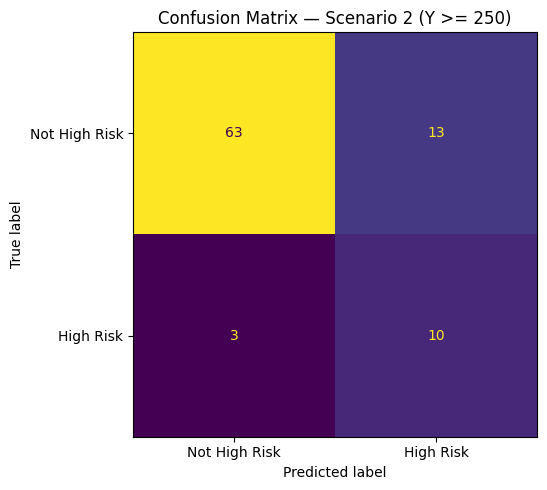

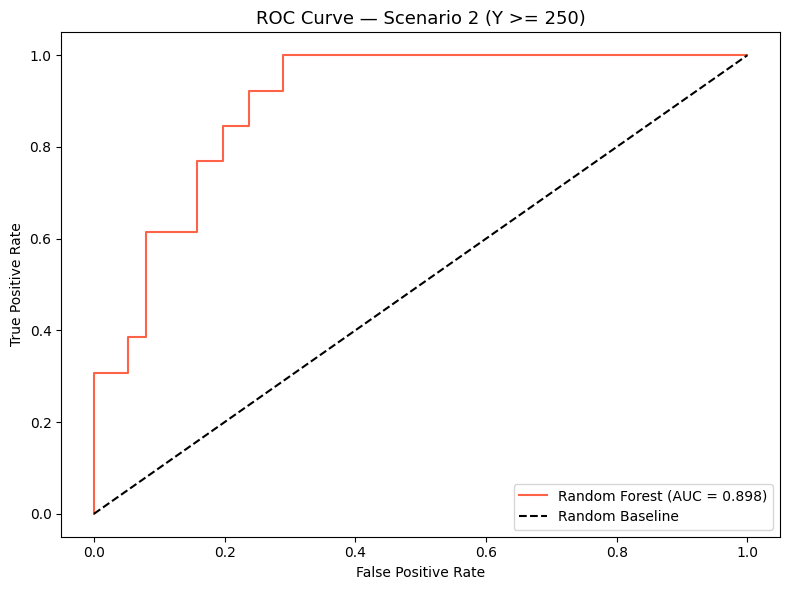

In [7]:
# # Creating the Confusion Matrice
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_s2),
                       display_labels=["Not High Risk", "High Risk"]).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Scenario 2 (Y >= 250)")
plt.tight_layout()
plt.show()

# ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_prob_s2)
auc_score = roc_auc_score(y_test, y_prob_s2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="tomato", label=f"Random Forest (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random Baseline")
ax.set_title("ROC Curve — Scenario 2 (Y >= 250)", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

The model correctly identified 10 out of 13 high-risk patients while 
missing only 3. The 13 false positives — healthy patients flagged as 
high-risk — are an acceptable tradeoff given the clinical priority of 
catching truly high-risk cases.

The ROC curve confirms strong discriminative power with AUC 0.898, well 
above the 0.5 random baseline. Combined with a cross-validated AUC of 
0.940 (±0.013) the model generalises consistently and reliably identifies 
high-risk patients despite the severe 85/15 class imbalance.

## 6. Conclusion — Scenario 1 (Y >= 250)

The Random Forest with SMOTE performed strongly despite the severe 85/15 
class imbalance, correctly identifying 10 out of 13 high-risk patients 
with a cross-validated AUC of 0.940 (±0.013) — the strongest result 
across both scenarios.

SMOTE proved essential here — without resampling the model would have 
collapsed toward predicting the majority class, making it clinically 
useless despite high accuracy. The combination of SMOTE and 
class_weight='balanced' ensured the minority class was given sufficient 
weight during training.

As with Scenario 1, the performance ceiling is partly explained by the 
dataset's information limits. High-risk progression above 250 is likely 
driven by unmeasured factors such as genetics, lifestyle and medication 
history. Enriching the feature set with such variables would be the most 
impactful next step for improving model performance beyond the current ceiling.